#### 데이터시각화_코드복습 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('./data/sales.csv', encoding='cp949')
df.head()

,ORDERID,PURCHASE_PAGE,CITY,CUSTOMER_TYPE,GENDER,PRODUCT_TYPE,UNIT_PRICE,QUANTITY,MILEAGE,TOTAL_PRICE,DATE,PURCHASE_TIME,PAYMENT,COGS,GROSS_MARGIN_PERCENTAGE,GROSS_INCOME,RATING
0,750-67-8428,A,Seoul,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Samsungpay,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Gyeonggi,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Naverpay,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Seoul,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Seoul,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Samsungpay,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Seoul,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Samsungpay,604.17,4.761905,30.2085,0.0


#### 히스토그램 

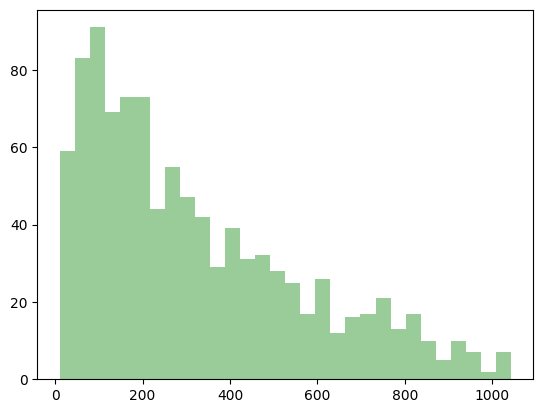

In [6]:
plt.hist(df['TOTAL_PRICE'], bins= 30, color='green', alpha=0.4)
plt.show()

In [7]:
df.head()

,ORDERID,PURCHASE_PAGE,CITY,CUSTOMER_TYPE,GENDER,PRODUCT_TYPE,UNIT_PRICE,QUANTITY,MILEAGE,TOTAL_PRICE,DATE,PURCHASE_TIME,PAYMENT,COGS,GROSS_MARGIN_PERCENTAGE,GROSS_INCOME,RATING
0,750-67-8428,A,Seoul,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Samsungpay,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Gyeonggi,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Naverpay,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Seoul,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Seoul,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Samsungpay,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Seoul,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Samsungpay,604.17,4.761905,30.2085,0.0


In [8]:
df['GENDER'].unique() 

array(['Female', 'Male'], dtype=object)

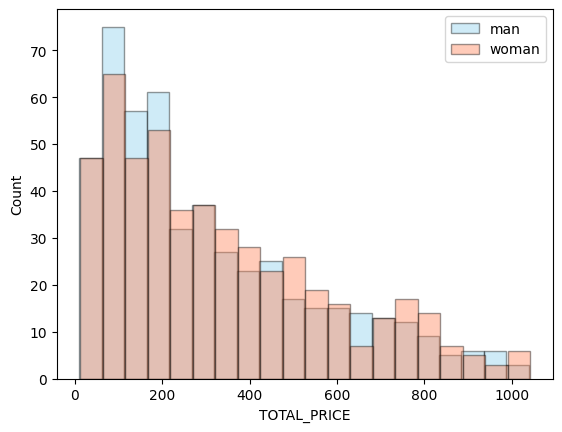

In [21]:
man_price = df[df['GENDER'] == 'Male']['TOTAL_PRICE']
woman_price = df[df['GENDER'] == 'Female']['TOTAL_PRICE']

plt.hist(man_price, bins=20, color='skyblue', alpha=0.4, linewidth=1, edgecolor='black', label='man')
plt.hist(woman_price, bins=20, color='coral', alpha=0.4, linewidth=1, edgecolor='black', label='woman')
plt.xlabel('TOTAL_PRICE')
plt.ylabel('Count')
plt.legend()
plt.show()

In [22]:
category_counts = df['CITY'].value_counts()
category_counts

CITY
Seoul       340
Incheon     332
Gyeonggi    328
Name: count, dtype: int64

<BarContainer object of 3 artists>

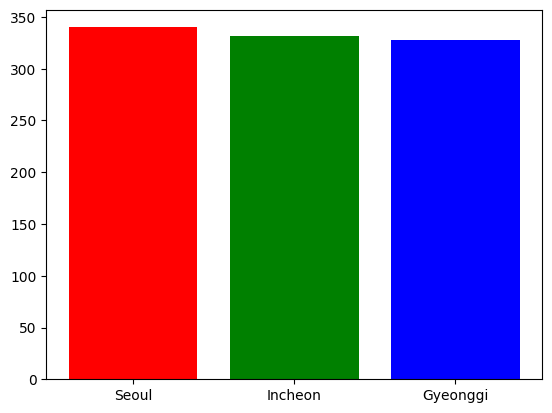

In [24]:
plt.bar(category_counts.index, category_counts, color=['r', 'g', 'b'])

In [25]:
city_gender = pd.crosstab(df['CITY'], df['GENDER'])
city_gender 

GENDER,Female,Male
CITY,,
Gyeonggi,178,150
Incheon,162,170
Seoul,161,179


In [26]:
city_gender.index

Index(['Gyeonggi', 'Incheon', 'Seoul'], dtype='object', name='CITY')

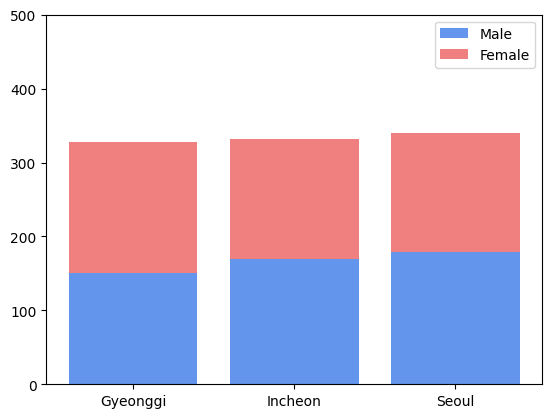

In [37]:
plt.bar(x=city_gender.index, height=city_gender['Male'], label='Male', color='cornflowerblue')
plt.bar(x=city_gender.index, height=city_gender['Female'], label='Female', color='lightcoral', bottom=city_gender['Male'])
plt.ylim([0, 500])
plt.legend()
plt.show()

In [36]:
city_price = df.groupby('CITY')['TOTAL_PRICE'].mean()
city_price

CITY
Gyeonggi    337.099715
Incheon     319.872506
Seoul       312.354031
Name: TOTAL_PRICE, dtype: float64

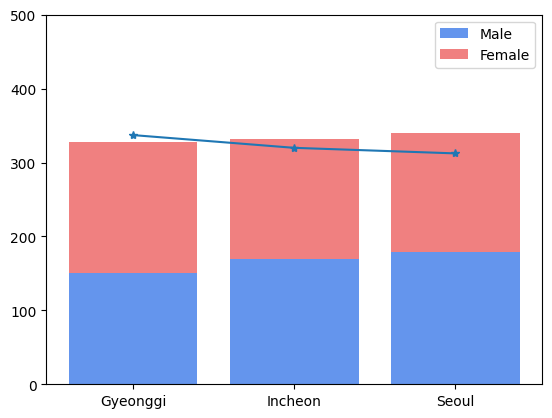

In [41]:
plt.bar(x=city_gender.index, height=city_gender['Male'], label='Male', color='cornflowerblue')
plt.bar(x=city_gender.index, height=city_gender['Female'], label='Female', color='lightcoral', bottom=city_gender['Male'])
plt.ylim([0, 500])
plt.plot(city_gender.index, city_price, '*-')
plt.legend()
plt.show()

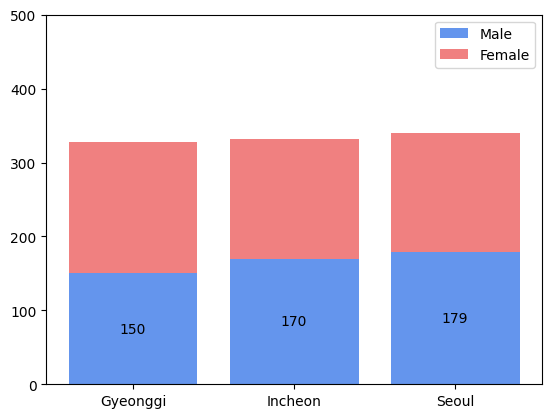

In [43]:
fig, ax = plt.subplots()

bar1 = ax.bar(x=city_gender.index, height=city_gender['Male'], label='Male', color='cornflowerblue')
bar2 = ax.bar(x=city_gender.index, height=city_gender['Female'], label='Female', color='lightcoral', bottom=city_gender['Male'])

ax.bar_label(bar1, label_type='center')

plt.ylim([0, 500])
plt.legend()
plt.show()

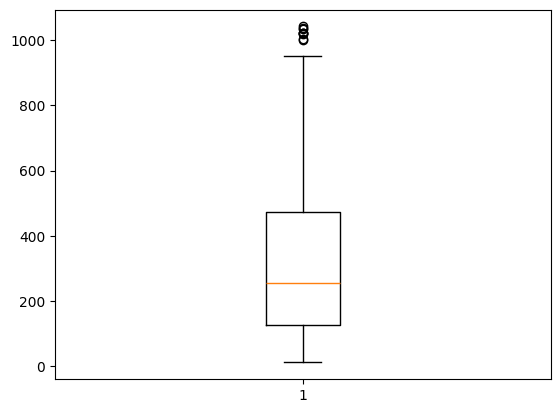

In [45]:
plt.boxplot(df['TOTAL_PRICE'])
plt.show()

In [46]:
man = df[df['GENDER']=='Male']
woman = df[df['GENDER']=='Female']

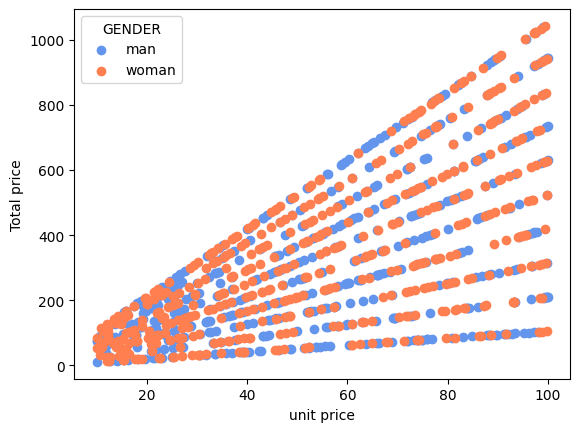

In [47]:
plt.scatter(man['UNIT_PRICE'], man['TOTAL_PRICE'], color='cornflowerblue', label='man')
plt.scatter(woman['UNIT_PRICE'], woman['TOTAL_PRICE'], color='coral', label='woman')
plt.legend(title='GENDER')
plt.xlabel('unit price')
plt.ylabel('Total price')
plt.show()


In [48]:
category_counts = df['CITY'].value_counts()
category_counts

CITY
Seoul       340
Incheon     332
Gyeonggi    328
Name: count, dtype: int64

In [49]:
city_idx = category_counts.index
city_idx

Index(['Seoul', 'Incheon', 'Gyeonggi'], dtype='object', name='CITY')

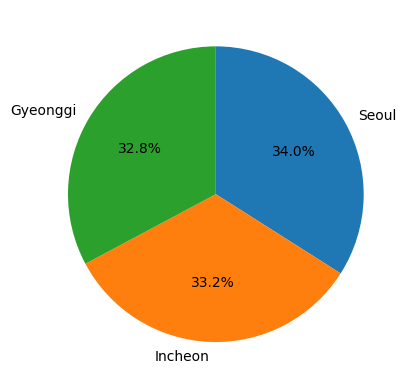

In [52]:
plt.pie(category_counts, labels=city_idx, startangle=90, counterclock=False, autopct='%1.1f%%')
plt.show()

In [54]:
city_list = list(category_counts.index)
explode = []
for city in city_list:
    print(city)
    if city == 'Seoul':
        explode.append(0.1)
    else:
        explode.append(0)

Seoul
Incheon
Gyeonggi


In [55]:
print(explode)

[0.1, 0, 0]


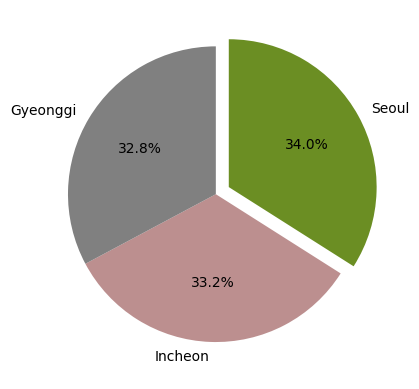

In [57]:
plt.pie(category_counts, labels=city_idx, startangle=90, 
        counterclock=False, autopct='%1.1f%%', explode = explode,
        colors=['olivedrab', 'rosybrown', 'gray'])
plt.show()

### Seaborn

In [58]:
import seaborn as sns 

<Axes: xlabel='TOTAL_PRICE', ylabel='Count'>

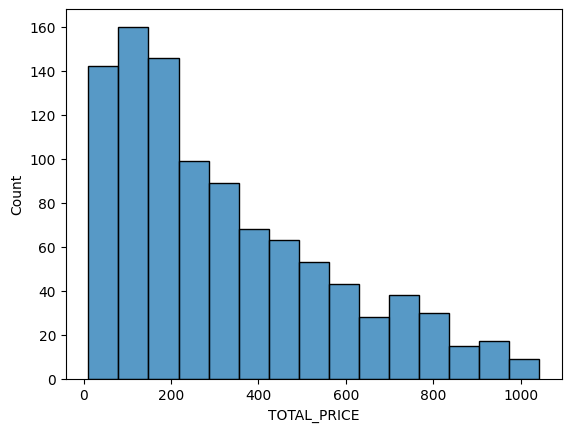

In [59]:
sns.histplot(data=df, x = 'TOTAL_PRICE')

<Axes: xlabel='TOTAL_PRICE', ylabel='Count'>

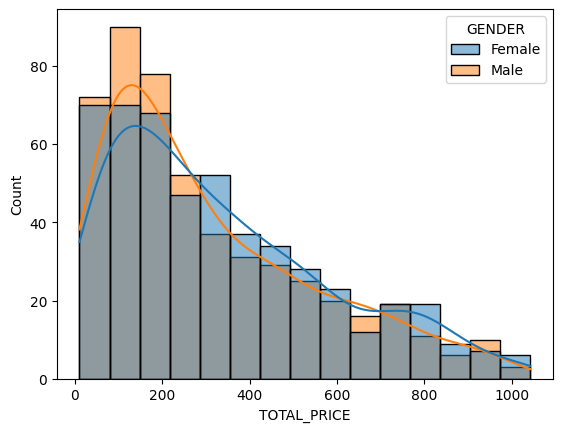

In [64]:
sns.histplot(data=df, x='TOTAL_PRICE', kde=True, hue='GENDER')

<Axes: xlabel='CITY', ylabel='count'>

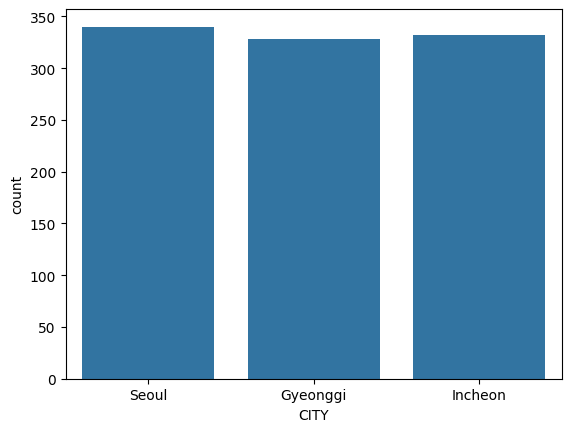

In [65]:
sns.countplot(data=df, x='CITY')


C:\Users\User\AppData\Local\Temp\ipykernel_15380\1272805408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CITY', palette=palette1)


<Axes: xlabel='CITY', ylabel='count'>

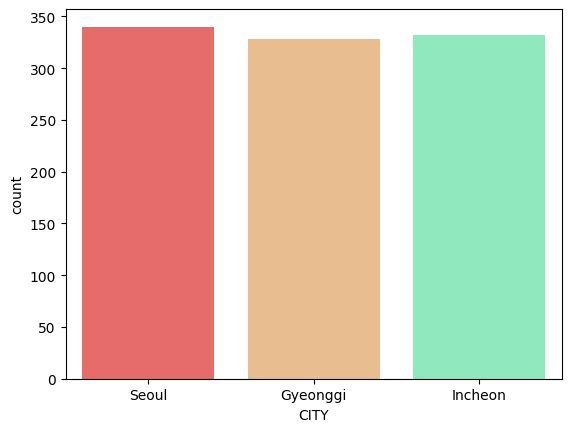

In [68]:
colors = ["#FA5858", "#F7BE81", "#81F7BE"]
palette1 = sns.color_palette(colors)
sns.countplot(data=df, x='CITY', palette=palette1)

<Axes: xlabel='CITY', ylabel='count'>

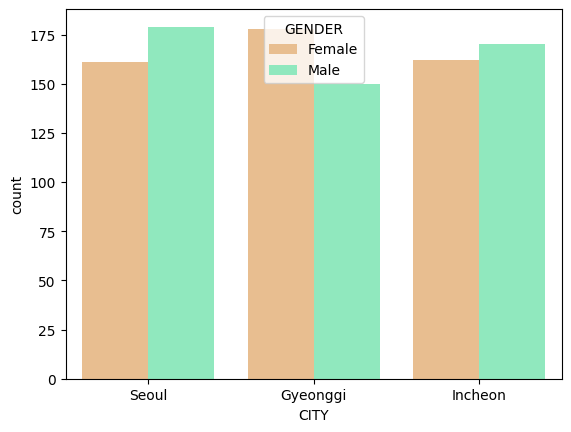

In [74]:
colors = ["#F7BE81", "#81F7BE"]
palette1 = sns.color_palette(colors)
sns.countplot(data=df, x='CITY', palette=palette1, hue='GENDER', color=palette1)

<Axes: ylabel='TOTAL_PRICE'>

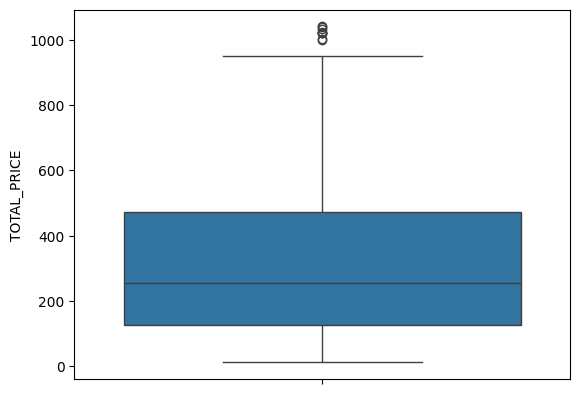

In [75]:
sns.boxplot(data=df, y='TOTAL_PRICE')

C:\Users\User\AppData\Local\Temp\ipykernel_15380\1800970803.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='GENDER', y='TOTAL_PRICE', palette=['r', 'g', 'b'])
C:\Users\User\AppData\Local\Temp\ipykernel_15380\1800970803.py:1: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(data=df, x='GENDER', y='TOTAL_PRICE', palette=['r', 'g', 'b'])


<Axes: xlabel='GENDER', ylabel='TOTAL_PRICE'>

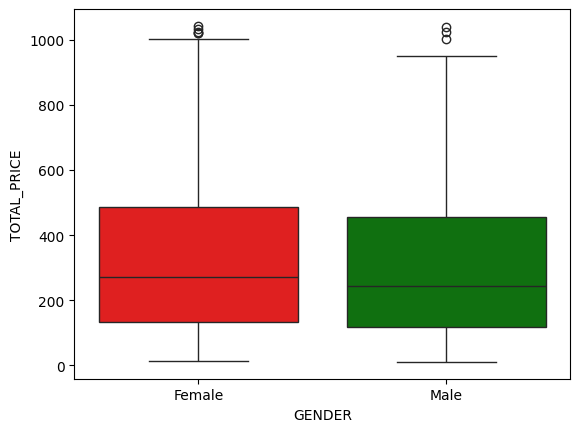

In [81]:
sns.boxplot(data=df, x='GENDER', y='TOTAL_PRICE', palette=['r', 'g', 'b'])